In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [4]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

======================================== sepal_length ========================================


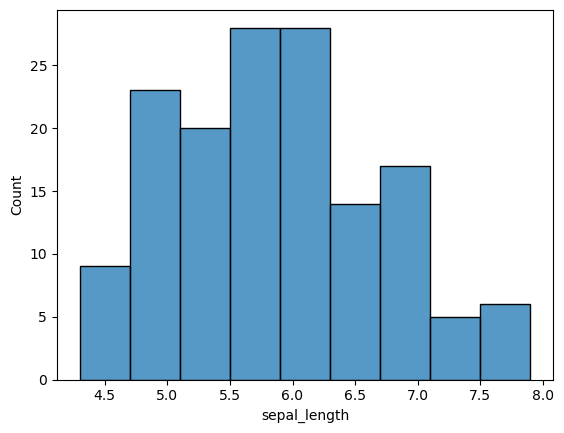

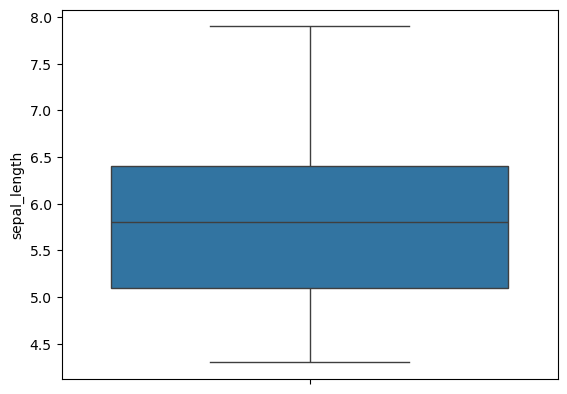

======================================== sepal_width ========================================


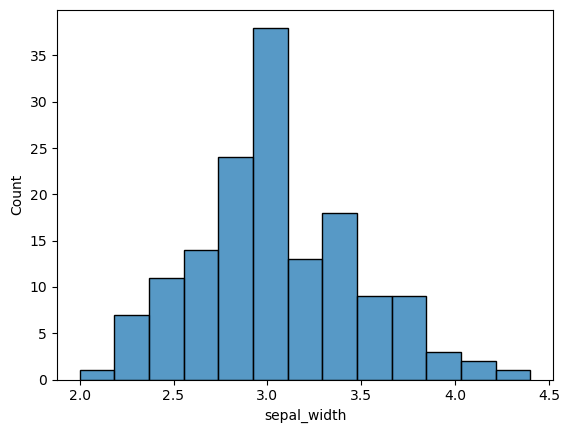

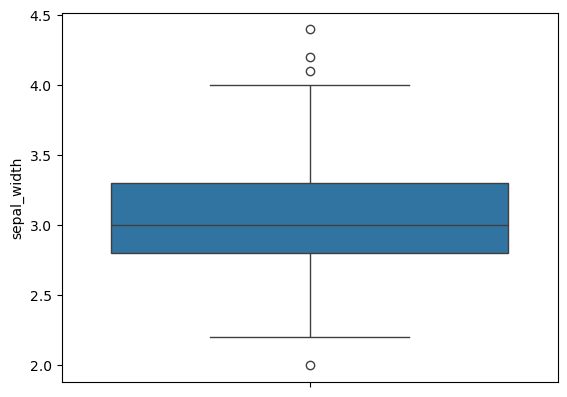

======================================== petal_length ========================================


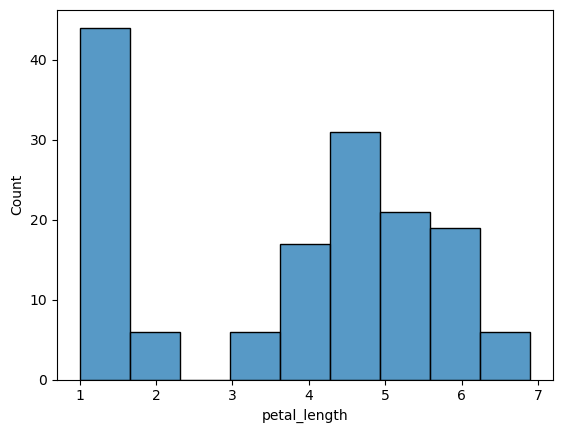

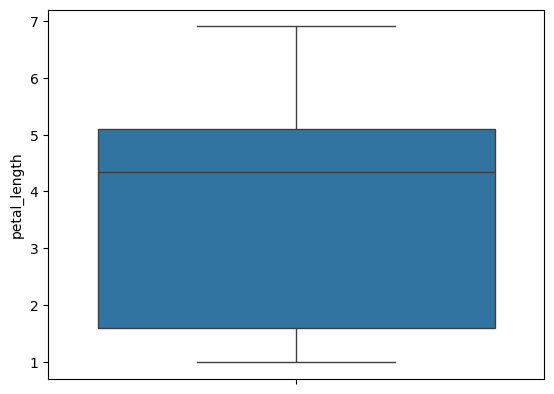

======================================== petal_width ========================================


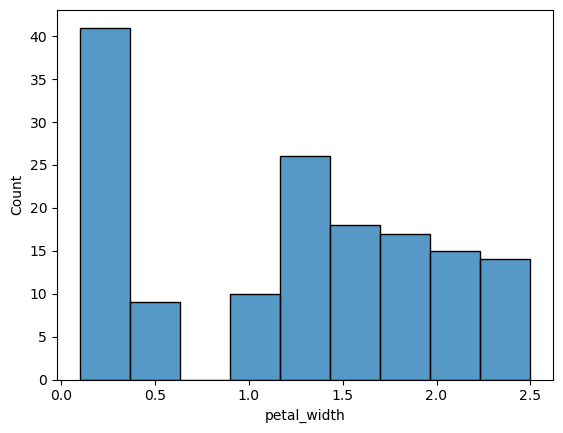

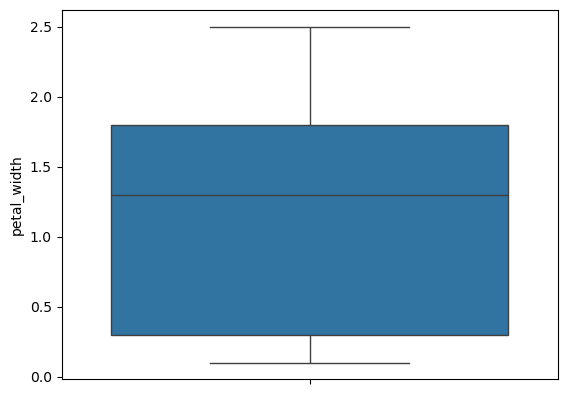

======================================== species ========================================


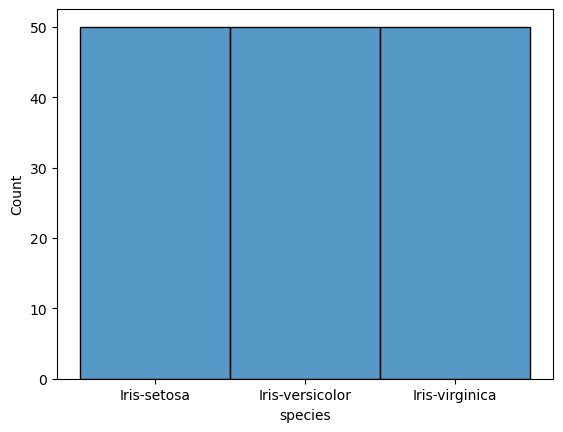

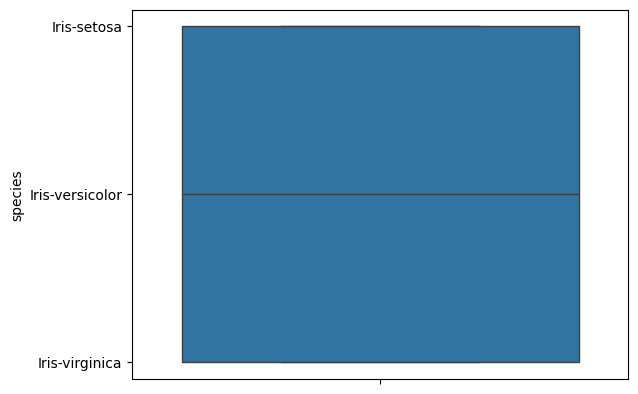

In [5]:
for col in data:
    print("=" *40, col, "=" *40)
    sns.histplot(data[col])
    plt.show()
    sns.boxplot(data[col])
    plt.show()

In [6]:
X = data.drop("species", axis=1)
y = data["species"]

* label encoding으로 변환(sparse_categorical_crossentropy) 
* ohe-hot encoding 변환(categorical_crossentropy)

In [7]:
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object

In [8]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
mms = MinMaxScaler()
mms.fit(X_train)
mms_X_train = mms.transform(X_train)
mms_X_test = mms.transform(X_test)
mms_X_train = pd.DataFrame(mms_X_train, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(mms_X_test, columns=X_test.columns, index=X_test.index)

In [14]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [15]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


# 텐서프로우로 다중분류 분석하기

In [16]:
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.metrics import classification_report

2025-12-04 08:44:08.483066: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 08:44:09.154580: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-04 08:44:11.447806: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [17]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 다중분류시에는 출력층의 클래스 수 만큼 node를 주어야 함, 활성함수는 softmax
model.summary()

I0000 00:00:1764805469.737746     557 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2025-12-04 08:44:48.524547: I external/local_xla/xla/service/service.cc:163] XLA service 0x71bec400b180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-04 08:44:48.524587: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-12-04 08:44:48.574828: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-04 08:44:48.764755: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


1/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5938 - loss: 0.9940

I0000 00:00:1764805490.287642     600 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 603ms/step - accuracy: 0.5750 - loss: 1.0195 - val_accuracy: 0.6667 - val_loss: 0.9991
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6417 - loss: 1.0037 - val_accuracy: 0.6667 - val_loss: 0.9870
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6500 - loss: 0.9906 - val_accuracy: 0.6667 - val_loss: 0.9768
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6500 - loss: 0.9786 - val_accuracy: 0.6667 - val_loss: 0.9655
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6583 - loss: 0.9662 - val_accuracy: 0.6667 - val_loss: 0.9536
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ -0s -147482us/step - accuracy: 0.6583 - loss: 0.9538 - val_accuracy: 0.7000 - val_loss: 0.9410
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6583 - loss: 0.9406 - val_accuracy: 0.7000 - val_loss: 0.9281
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6583 - loss: 0.9272 - val_accuracy: 0.7000 - val_loss: 0.91

Epoch 52/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6583 - loss: 0.4912 - val_accuracy: 0.7000 - val_loss: 0.4722
Epoch 53/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6583 - loss: 0.4875 - val_accuracy: 0.7000 - val_loss: 0.4686
Epoch 54/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6583 - loss: 0.4841 - val_accuracy: 0.7000 - val_loss: 0.4651
Epoch 55/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6583 - loss: 0.4806 - val_accuracy: 0.7000 - val_loss: 0.4616
Epoch 56/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6583 - loss: 0.4776 - val_accuracy: 0.7000 - val_loss: 0.4583
Epoch 57/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6583 - loss: 0.4742 - val_accuracy: 0.7000 - val_loss: 0.4551
Epoch 58/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6583 - loss: 0.4711 - val_accuracy: 0.7000 - val_loss: 0.4521
Epoch 59/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 0.4682 - val_accuracy: 0.7000 - v

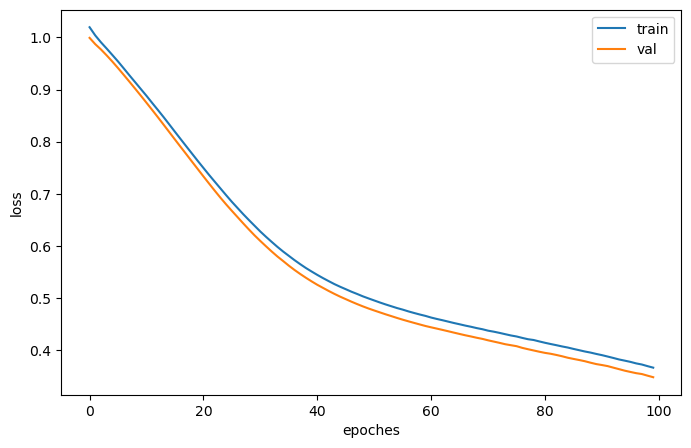

In [18]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=32, validation_data=(mms_X_test, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show() 

In [19]:
pred = model.predict(mms_X_test)
pred= pd.DataFrame(pred)
pred
# pred= pred[0].apply(lambda x: 1 if x > 0.5 else 0)
# print(classification_report(y_test, pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


,0,1,2
0,0.013831,0.523002,0.463167
1,0.992078,0.000186,0.007736
2,0.002394,0.169716,0.827891
3,0.012013,0.489850,0.498137
4,0.009491,0.437089,0.553420
5,0.982349,0.000907,0.016744
6,0.023356,0.556650,0.419994
7,0.004186,0.279877,0.715936
8,0.013869,0.329375,0.656756
9,0.018252,0.554298,0.427450
